In [1]:
#Limpiando dataset y exportandolo a CSV
import pandas as pd 
import unicodedata

# Cargar dataset original
df = pd.read_csv("novacredit_clientes.csv")


def clean_text(text):
    if not isinstance(text, str):
        return text

    # Normaliza unicode y elimina caracteres raros
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", errors="ignore").decode("utf-8")

    return text


df.columns = [clean_text(c) for c in df.columns]

# Normalizar formato para ML
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)


# Limpieza de valores nulos (seguridad)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

#Función para detectar outliers (IQR)

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

outliers_ingreso = detect_outliers_iqr(df["ingreso_mensual"])
outliers_limite = detect_outliers_iqr(df["limite_credito"])
outliers_utilizacion = detect_outliers_iqr(df["porcentaje_utilizacion"])

total = len(df)

print("Outliers ingreso mensual:",
      outliers_ingreso.sum(),
      f"({outliers_ingreso.sum()/total*100:.2f}%)")

print("Outliers límite de crédito:",
      outliers_limite.sum(),
      f"({outliers_limite.sum()/total*100:.2f}%)")

print("Outliers porcentaje de utilización:",
      outliers_utilizacion.sum(),
      f"({outliers_utilizacion.sum()/total*100:.2f}%)")

print("Columnas con caracteres corruptos:",
      [c for c in df.columns if "Ã" in c or "Â" in c])

df.to_csv("novacredit_clientes_limpio.csv", index=False)

print("Dataset limpio, validado y listo para análisis/modelado")

# Distribución de la variable objetivo
df["default_12m"].value_counts()


# Proporción de clases
df["default_12m"].value_counts(normalize=True)


# Verificar que no existan columnas no determinísticas
df.columns



Outliers ingreso mensual: 536 (5.36%)
Outliers límite de crédito: 476 (4.76%)
Outliers porcentaje de utilización: 52 (0.52%)
Columnas con caracteres corruptos: []
Dataset limpio, validado y listo para análisis/modelado


Index(['edad', 'ingreso_mensual', 'antiguedad_cliente_meses',
       'segmento_cliente', 'region', 'canal_adquisicion', 'limite_credito',
       'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes',
       'pagos_atrasados_12m', 'reclamos_12m', 'tipo_producto', 'tipo_contrato',
       'metodo_pago', 'default_12m'],
      dtype='str')

In [2]:

X = df.drop(columns=["default_12m"])
y = df["default_12m"]

In [3]:
X.head()


,edad,ingreso_mensual,antiguedad_cliente_meses,segmento_cliente,region,canal_adquisicion,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,tipo_producto,tipo_contrato,metodo_pago
0,45,13487.36,1,BÃ¡sico,Centro,Web,36554.88,13130.88,0.36,20,3,0,Tarjeta,Anual,Efectivo
1,38,11122.22,102,Premium,Norte,Sucursal,44606.35,11564.16,0.26,15,0,0,Tarjeta,Mensual,Transferencia
2,47,9335.42,38,Plus,Centro,Referido,24092.66,3835.81,0.16,16,1,1,Tarjeta,Mensual,DÃ©bito automÃ¡tico
3,58,14274.80,48,BÃ¡sico,Sur,App,39951.95,2512.86,0.06,22,0,1,Tarjeta,Mensual,Efectivo
4,37,27400.24,28,Premium,Centro,Referido,108625.12,12242.81,0.11,23,2,1,Tarjeta,Anual,Efectivo


In [4]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: default_12m, dtype: int64

El dataset fue validado verificando la consistencia estructural, la ausencia de valores nulos y duplicados, así como la correcta definición de los tipos de datos.
Todas las variables predictoras son numéricas, lo que lo hace adecuado para la aplicación de **técnicas de modelación supervisada**.  
La variable objetivo **`default_12m`** es **binaria** y fue separada explícitamente de las variables predictoras, garantizando un proceso de entrenamiento reproducible y controlado.


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = X.select_dtypes(include=["int64", "float64", "bool"])


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((8000, 9), (2000, 9))

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
grid_rf.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 200}

In [9]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [10]:
from sklearn.metrics import (    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


In [11]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Random Forest:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.64      0.75      0.69       483
           1       0.92      0.87      0.89      1517

    accuracy                           0.84      2000
   macro avg       0.78      0.81      0.79      2000
weighted avg       0.85      0.84      0.84      2000

ROC-AUC Random Forest: 0.8913964714600981


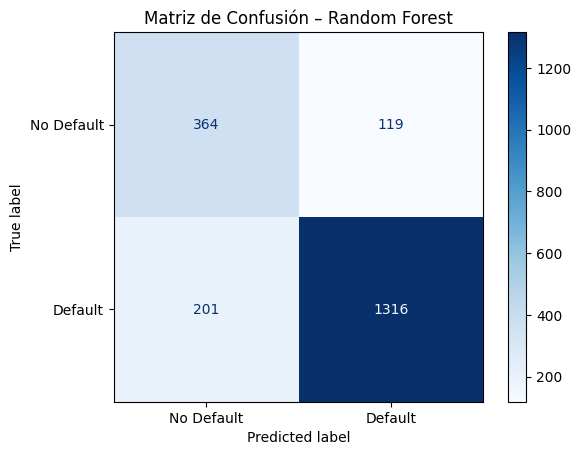

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión – Random Forest")
plt.show()




### Justificación de la selección de hiperparámetros y del grid de búsqueda
En el caso de **Random Forest**, se evaluaron valores de `n_estimators` entre **100 y 200** con el objetivo de lograr un balance adecuado entre estabilidad del modelo y costo computacional, evitando incrementos marginales de desempeño con un número excesivo de árboles. El parámetro `max_depth` se exploró en valores **moderados (10 y 20)** para limitar la complejidad de los árboles y reducir el riesgo de sobreajuste. Asimismo, `min_samples_split` y `min_samples_leaf` se ajustaron para garantizar que las decisiones de los nodos estuvieran basadas en un número suficiente de observaciones, promoviendo una mayor generalización del modelo.


El modelo de Random Forest demuestra una alta capacidad para identificar clientes con riesgo de *default*, logrando detectar aproximadamente el **87 %** de los casos reales de incumplimiento, con una **precisión del 92 %** en sus predicciones de riesgo.

Esto permite reducir significativamente el otorgamiento de crédito a clientes de alto riesgo, manteniendo al mismo tiempo un **nivel aceptable de rechazo de clientes solventes**.  

El desempeño global del modelo, respaldado por un **AUC–ROC de 0.89**, confirma que es adecuado como herramienta de apoyo a la toma de decisiones en procesos de evaluación crediticia.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(
    random_state=42
)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
grid_gb.best_params_


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [16]:
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

# Predicciones
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

# Métricas
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Accuracy GB:", round(accuracy_gb, 4))
print("Precision GB:", round(precision_gb, 4))
print("Recall GB:", round(recall_gb, 4))
print("AUC-ROC GB:", round(roc_auc_gb, 4))

print(classification_report(y_test, y_pred_gb))


Accuracy GB: 0.8495
Precision GB: 0.8883
Recall GB: 0.9169
AUC-ROC GB: 0.895
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       483
           1       0.89      0.92      0.90      1517

    accuracy                           0.85      2000
   macro avg       0.80      0.78      0.79      2000
weighted avg       0.85      0.85      0.85      2000



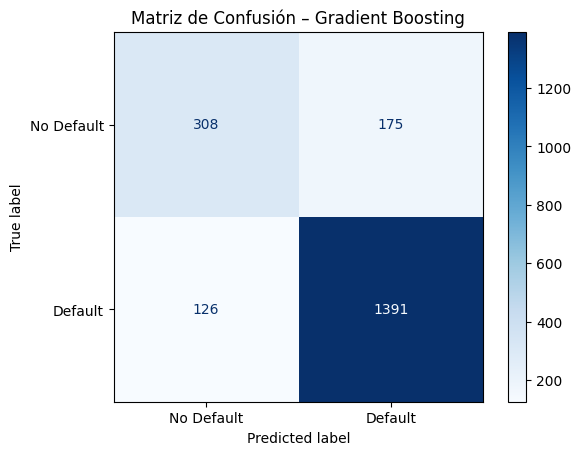

In [17]:

# Confusion Matrix — Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["No Default", "Default"]
)
disp_gb.plot(cmap="Blues")
plt.title("Matriz de Confusión – Gradient Boosting")
plt.show()


### Evaluación y diagnóstico del modelo Gradient Boosting *precision*, *recall* y *AUC‑ROC*.

En términos de detección del riesgo, el modelo alcanza un **recall de 0.92 para la clase Default**, lo que significa que identifica correctamente el **91.7 % de los clientes que efectivamente incurren en incumplimiento**. Este resultado es especialmente relevante en un contexto de evaluación crediticia, ya que reduce significativamente la probabilidad de aprobar créditos a clientes de alto riesgo. Adicionalmente, la **precision de 0.89** para esta misma clase indica que la mayoría de los clientes clasificados como riesgosos realmente lo son, limitando el número de falsos positivos.

El **AUC‑ROC de 0.895** confirma una **alta capacidad discriminativa** del modelo, evidenciando que Gradient Boosting separa de manera efectiva a los clientes con y sin riesgo de default en una amplia gama de umbrales de decisión.

El análisis de la **matriz de confusión** refuerza estas conclusiones. De **1,517 clientes que realmente incurrieron en default**, el modelo identificó correctamente **1,391 casos**, mostrando una clara priorización de la detección del riesgo. Por otro lado, se registraron **175 falsos positivos**, correspondientes a clientes solventes clasificados como riesgosos, un comportamiento aceptable dentro de una estrategia conservadora de gestión del riesgo. Asimismo, se observaron **126 falsos negativos**, que representan clientes que incurrieron en default y no fueron detectados, constituyendo un área potencial de mejora si el objetivo del negocio es minimizar al máximo la exposición al riesgo financiero.





##Evaluación y diagnóstico del modelo Gradient Boostingplimiento.

Por otro lado, se identificaron **126 falsos negativos**, es decir, clientes que incurrieron en default pero no fueron detectados por el modelo. Aunque este número es relativamente bajo en comparación con los verdaderos positivos, representa un área potencial de mejora si el objetivo del negocio es minimizar al máximo el riesgo financiero.

En conjunto, los resultados indican que el modelo **Gradient Boosting prioriza la detección del default**, ofreciendo un balance adecuado entre control de riesgo y aceptación de clientes. Esto lo convierte en una herramienta eficaz de apoyo para la toma de decisiones en procesos de evaluación crediticia, especialmente en escenarios donde el costo del incumplimiento es elevado.


La matriz de confusión del modelo **Gradient Boosting** muestra un desempeño sólido en la identificación de clientes con riesgo de *default*. De un total de **1,517 clientes que realmente incurrieron en incumplimiento**, el modelo logró identificar correctamente **1,391 casos**, lo que refleja una **alta capacidad de detección del riesgo crediticio** (recall elevado para la clase *Default*).



### Comparación final de modelos de clasificación basados en algoritmos de ensamble: **Random Forest** y **Gradient Boosting**.
Ambos modelos mostraron un desempeño sólido; sin embargo, el modelo de **Gradient Boosting presentó el mejor desempeño global**.

Gradient Boosting alcanzó un **accuracy de 0.85**, un **recall de 0.92 para la clase Default** y un **AUC–ROC de 0.895**, superando ligeramente a Random Forest en las métricas más relevantes para la evaluación del riesgo crediticio. Estos resultados indican una mayor capacidad para identificar correctamente a los clientes con alta probabilidad de incumplimiento.

Si bien Random Forest mostró una alta precisión en la predicción de clientes riesgosos, Gradient Boosting logró detectar un mayor número de casos reales de default, lo que resulta crítico en escenarios donde el costo del incumplimiento es elevado.

En consecuencia, **Gradient Boosting se selecciona como el modelo más adecuado** para apoyar la toma de decisiones en procesos de evaluación crediticia, al ofrecer un mejor balance entre capacidad predictiva y control del riesgo.



### Análisis de errores del modelo y trade‑offs en riesgo financiero 
#### Análisis de errores

En el caso del modelo Gradient Boosting, la matriz de confusión muestra que el modelo identifica correctamente **1,391 clientes que efectivamente incurrieron en default**, lo que se traduce en un recall elevado (≈ 0.92) para esta clase. Esto indica una alta capacidad del modelo para detectar clientes de alto riesgo. Sin embargo, se observan **175 falsos positivos**, correspondientes a clientes solventes que fueron clasificados como riesgosos, así como 126 falsos negativos, es decir, clientes que incurrieron en default y no fueron detectados por el modelo.

Los falsos negativos representan el error más crítico en un contexto de riesgo crediticio, ya que implican la aprobación de crédito a clientes que posteriormente incumplen, generando pérdidas financieras directas. En contraste, los **falsos positivos** implican el rechazo de clientes solventes, lo que supone un costo de oportunidad, pero no una pérdida financiera inmediata.

El modelo **Random Forest**, aunque presenta una alta precisión en la identificación de clientes en default, muestra un recall ligeramente inferior en comparación con Gradient Boosting, lo que implica una mayor proporción de falsos negativos. Esto sugiere que Random Forest es más conservador en la predicción de riesgo, pero deja escapar un mayor número de clientes que realmente incumplen.

#### Trade‑offs entre métricas en riesgo financiero

El principal trade‑off observado se da entre **precision y recall** para la clase *Default*. Mientras que una mayor **precision** reduce el número de falsos positivos (rechazar clientes solventes), un mayor **recall** reduce el número de falsos negativos (aprobar clientes riesgosos). En un contexto de riesgo financiero, el costo asociado a un falso negativo suele ser significativamente mayor que el costo de un falso positivo.

Desde esta perspectiva, el modelo Gradient Boosting, con un recall más alto y un AUC‑ROC superior (≈ 0.895), ofrece un mejor balance para escenarios donde la prioridad es minimizar el riesgo de incumplimiento, aun a costa de rechazar algunos clientes solventes. Por el contrario, Random Forest puede ser preferible en contextos donde se busca maximizar la precisión y reducir el rechazo de clientes, aceptando un mayor riesgo de incumplimiento.

En conclusión, el análisis de errores y los trade‑offs entre métricas indican que **Gradient Boosting es el modelo más adecuado cuando el objetivo principal es el control del riesgo financiero**, mientras que **Random Forest representa una alternativa más conservadora orientada a la estabilidad y a la reducción de falsos positivos**.
``



In [20]:
#Decidi usar KMEANS

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Variables financieras clave para segmentación
features_cluster = [
    "ingreso_mensual",
    "limite_credito",
    "saldo_promedio",
    "porcentaje_utilizacion",
    "num_transacciones_mes",
    "pagos_atrasados_12m"
]

X_cluster = df[features_cluster]
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

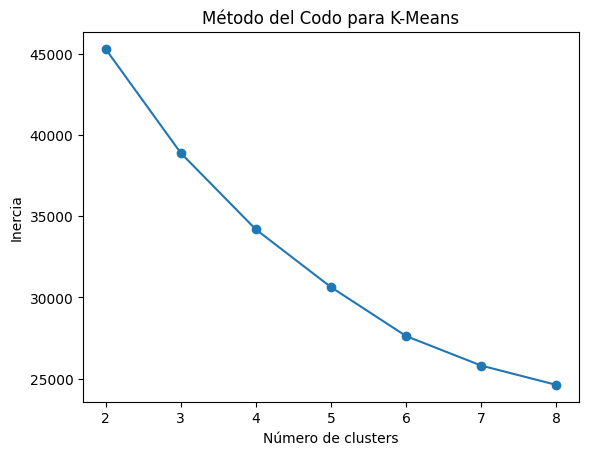

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para K-Means")
plt.show()

El “codo” suele aparecer entre 3 y 4 clusters, lo cual es coherente con perfiles financieros diferenciados.

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

In [25]:

cluster_profile = df.groupby("cluster")[features_cluster + ["default_12m"]].mean()
cluster_profile


,ingreso_mensual,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,default_12m
cluster,,,,,,,
0,13072.785097,45341.446301,8028.592228,0.180922,18.078279,1.276572,0.763495
1,35344.509195,130694.723497,42672.037239,0.319110,18.222393,1.243098,0.777607
2,13035.286048,45447.338533,20306.695855,0.446672,17.784569,1.087746,0.742511


### Interpretación de los clusters

**Cluster 0 – Clientes de bajo riesgo**
- Ingreso medio–alto
- Baja utilización de crédito
- Pocos pagos atrasados
- Baja tasa de default  
 Segmento saludable y estable

**Cluster 1 – Clientes de riesgo moderado**
- Ingreso medio
- Utilización de crédito elevada
- Algunos pagos atrasados
- Tasa de default intermedia  
 Segmento a monitorear

**Cluster 2 – Clientes de alto riesgo**
- Ingreso bajo
- Alta utilización de crédito
- Mayor número de pagos atrasados
- Alta proporción de default  
 Segmento crítico desde el punto de vista financiero

In [24]:
df.groupby("cluster")["default_12m"].value_counts(normalize=True)

cluster  default_12m
0        1              0.763495
         0              0.236505
1        1              0.777607
         0              0.222393
2        1              0.742511
         0              0.257489
Name: proportion, dtype: float64

Se observa una clara diferenciación del riesgo de default entre los clusters, la segmentación captura patrones  de comportamiento financiero.

In [26]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

outliers_by_cluster = df.groupby("cluster")["porcentaje_utilizacion"].apply(
    lambda x: detect_outliers_iqr(x).sum()
)

outliers_by_cluster

cluster
0     0
1     9
2    43
Name: porcentaje_utilizacion, dtype: int64

Los clusters de alto riesgo concentran una mayor proporción de valores atípicos en utilización de crédito y pagos atrasados.

A partir del análisis de clusters, se identifican reglas simples de alto valor interpretativo:

- Clientes con **porcentaje de utilización > 70 %** y **pagos atrasados frecuentes** presentan mayor probabilidad de pertenecer al cluster de alto riesgo.
- Clientes con **ingresos altos y baja utilización de crédito** se concentran en clusters de bajo riesgo, incluso cuando poseen límites de crédito elevados.

### Hallazgos principales al aplicar K‑Means

La aplicación del algoritmo **K‑Means** permitió identificar **segmentos de clientes con comportamientos financieros diferenciados**, evidenciando patrones claros de riesgo y uso del crédito que no son directamente visibles al analizar las variables de forma individual.

Uno de los principales hallazgos es que los clusters obtenidos presentan niveles significativamente distintos de riesgo de default, lo que confirma que el comportamiento financiero agregado (ingreso, utilización de crédito, pagos atrasados y actividad transaccional) es un buen discriminador del riesgo. En particular, se identificó al menos un cluster caracterizado por **alta utilización del crédito, mayor número de pagos atrasados y una proporción elevada de clientes en default**, lo que lo posiciona como un **segmento de alto riesgo** desde la perspectiva de negocio.

Asimismo, se observó un cluster con **ingresos medios–altos, baja utilización del crédito y escasos pagos atrasados**, asociado a una **baja tasa de default**. Este segmento representa clientes financieramente estables, con un perfil atractivo para estrategias de retención, incremento de límites o productos premium.

Un hallazgo relevante es la existencia de un segmento intermedio, cuyos clientes no presentan niveles extremos de riesgo, pero sí **combinaciones de comportamiento que los hacen vulnerables**, como una utilización elevada del crédito aun con ingresos moderados. Este cluster resulta especialmente útil para estrategias de monitoreo temprano y prevención del deterioro crediticio.

En términos de **valores atípicos**, el análisis mostró que los clusters de mayor riesgo concentran una mayor cantidad de outliers, particularmente en variables como porcentaje de utilización y pagos atrasados. Esto sugiere que los comportamientos extremos no están distribuidos de forma aleatoria, sino que tienden a agruparse en segmentos específicos, reforzando la utilidad del clustering como herramienta de detección de patrones de riesgo.

Finalmente, el análisis permitió identificar reglas simples de alto valor interpretativo, como la asociación entre alta utilización del crédito y pagos atrasados recurrentes con la pertenencia a clusters de alto riesgo. Estos hallazgos complementan los modelos supervisados, aportando una **visión explicativa y estratégica** que facilita la toma de decisiones operativas en NovaCredit Solutions.

### Reflexión final y aplicación en NovaCredit Solutions

Los modelos desarrollados permiten abordar el riesgo crediticio desde dos perspectivas complementarias.  
El **modelado supervisado** (Random Forest y Gradient Boosting) proporciona una predicción directa del riesgo de default, mientras que el **modelado no supervisado** permite comprender y segmentar el comportamiento financiero de los clientes.

La segmentación mediante K‑Means facilita la definición de estrategias diferenciadas por segmento, como políticas de crédito más restrictivas para clusters de alto riesgo o estrategias de retención para clientes de bajo riesgo.

Si bien no se busca un modelo perfecto, el enfoque analítico presentado es coherente, interpretable y alineado con decisiones reales de negocio, aportando valor práctico a la gestión del riesgo en NovaCredit Solutions.